# Import focal-plane pressure-field measurements

Read `point_manifest.csv` and the averaged A-mode waveform at every point in `pressure map_7p37MHz_10Vpp_focal plane`.

`amplitude_v` has shape **(scan axis 1, scan axis 2, samples)**. Coordinates are `axis1_mm`, `axis2_mm`, and `time_s`; physical axis names come from the manifest. Zigzag acquisition order is mapped by grid coordinates, never reshaped directly.

All sampling intervals must agree. The recorded time origins differ slightly, so the default linearly interpolates each waveform onto one time axis within their common overlap, without extrapolation. Original data remain in `waveforms_by_point`. Set `align_time_axes = False` to require identical recorded times instead.

Calibration below converts voltage to Pa at a specified frequency.

In [1]:
from pathlib import Path
import io
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt


folder_name =  "pressure map_7p37MHz_10Vpp_focal plane" # "pressure map_2MHz_10Vpp_ focal plane" #
measurement_frequency_mhz = 7.37  #2 # in MHz, USER SETTING

align_time_axes = True
sampling_interval_rtol = 1e-6

project_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / "data" / "Measurements - Onda hydrophone data - 2026").is_dir()), None)
if project_root is None:
    raise FileNotFoundError("Start the notebook from the project root or src directory.")
measurement_root = project_root / "data" / "Measurements - Onda hydrophone data - 2026" / folder_name
manifest_df = pd.read_csv(measurement_root / "point_manifest.csv")
display(manifest_df.head())

,point_order,row_index,col_index,row_axis_role,row_axis_name,col_axis_role,col_axis_name,direction,algorithm,scan_axis,cross_axis,scan_mm,cross_mm,scan_pulse,cross_pulse,measurement_csv
0,1,1,1,axis_2,Z,axis_1,Y,forward,Zigzag,Y,Z,0.000000,0.0,0,0,pressure_mode_measurements/point_0001_r001_c00...
1,2,1,2,axis_2,Z,axis_1,Y,forward,Zigzag,Y,Z,0.363636,0.0,1818,0,pressure_mode_measurements/point_0002_r001_c00...
2,3,1,3,axis_2,Z,axis_1,Y,forward,Zigzag,Y,Z,0.727273,0.0,3636,0,pressure_mode_measurements/point_0003_r001_c00...
3,4,1,4,axis_2,Z,axis_1,Y,forward,Zigzag,Y,Z,1.090909,0.0,5455,0,pressure_mode_measurements/point_0004_r001_c00...
4,5,1,5,axis_2,Z,axis_1,Y,forward,Zigzag,Y,Z,1.454545,0.0,7273,0,pressure_mode_measurements/point_0005_r001_c00...


In [2]:
def unique_value(column):
    values = manifest_df[column].dropna().unique()
    if len(values) != 1 or manifest_df[column].isna().any():
        raise ValueError(f"Expected one consistent value for {column}")
    return values[0]

row_role, col_role = unique_value("row_axis_role"), unique_value("col_axis_role")
if {row_role, col_role} != {"axis_1", "axis_2"}:
    raise ValueError("Manifest must define axis_1 and axis_2")
# scan_mm corresponds to columns; cross_mm corresponds to rows.
axis1_column = "scan_mm" if col_role == "axis_1" else "cross_mm"
axis2_column = "cross_mm" if row_role == "axis_2" else "scan_mm"
axis1_name = unique_value("col_axis_name" if col_role == "axis_1" else "row_axis_name")
axis2_name = unique_value("row_axis_name" if row_role == "axis_2" else "col_axis_name")
axis1_mm = np.sort(manifest_df[axis1_column].unique())
axis2_mm = np.sort(manifest_df[axis2_column].unique())
if not np.isfinite(axis1_mm).all() or not np.isfinite(axis2_mm).all():
    raise ValueError("Grid coordinates must be finite")
if manifest_df.duplicated([axis1_column, axis2_column]).any():
    raise ValueError("Duplicate grid locations in manifest")
if len(manifest_df) != len(axis1_mm) * len(axis2_mm):
    raise ValueError("Manifest does not contain a complete rectangular grid")
if manifest_df["point_order"].duplicated().any() or manifest_df["measurement_csv"].duplicated().any():
    raise ValueError("Duplicate point IDs or waveform paths")

waveforms_by_point = {}
point_rows = []
for _, point in manifest_df.iterrows():
    path = measurement_root / point["measurement_csv"]
    frame = pd.read_csv(path, comment="#")
    t = frame["Time (s)"].to_numpy(dtype=float)
    v = frame["Amplitude (V)"].to_numpy(dtype=float)
    if len(t) < 2 or not np.isfinite(t).all() or not np.isfinite(v).all():
        raise ValueError(f"Invalid waveform in {path}")
    intervals = np.diff(t)
    dt = float(np.median(intervals))
    if dt <= 0 or not np.allclose(intervals, dt, rtol=sampling_interval_rtol, atol=0):
        raise ValueError(f"Nonuniform or nonincreasing time axis in {path}")
    point_id = int(point["point_order"])
    waveforms_by_point[point_id] = frame
    point_rows.append({"point_order": point_id, "sample_count": len(t),
                       "start_time_s": t[0], "end_time_s": t[-1],
                       "sampling_interval_s": dt, "sampling_rate_hz": 1 / dt})
point_summary_df = pd.DataFrame(point_rows).set_index("point_order")
reference_time_s = next(iter(waveforms_by_point.values()))["Time (s)"].to_numpy(dtype=float)
sampling_interval_s = float(point_summary_df["sampling_interval_s"].iloc[0])
if not np.allclose(point_summary_df["sampling_interval_s"], sampling_interval_s,
                   rtol=sampling_interval_rtol, atol=0):
    raise ValueError("Sampling rates differ between points")
if point_summary_df["sample_count"].nunique() != 1:
    raise ValueError("Sample counts differ between points")
sampling_rate_hz = 1 / sampling_interval_s
identical_time_axes = all(np.array_equal(frame["Time (s)"].to_numpy(), reference_time_s)
                          for frame in waveforms_by_point.values())
if identical_time_axes:
    time_s = reference_time_s.copy()
elif not align_time_axes:
    raise ValueError("Recorded time axes differ; enable align_time_axes to interpolate")
else:
    overlap_start = point_summary_df["start_time_s"].max()
    overlap_end = point_summary_df["end_time_s"].min()
    # Keep the first point's sample times only where every waveform has coverage.
    time_s = reference_time_s[(reference_time_s >= overlap_start) & (reference_time_s <= overlap_end)]
    if len(time_s) < 2:
        raise ValueError("Insufficient shared time coverage")

amplitude_v = np.empty((len(axis1_mm), len(axis2_mm), len(time_s)), dtype=float)
point_id_grid = np.empty((len(axis1_mm), len(axis2_mm)), dtype=int)
for _, point in manifest_df.iterrows():
    point_id = int(point["point_order"])
    frame = waveforms_by_point[point_id]
    i = int(np.searchsorted(axis1_mm, point[axis1_column]))
    j = int(np.searchsorted(axis2_mm, point[axis2_column]))
    amplitude_v[i, j, :] = np.interp(time_s, frame["Time (s)"], frame["Amplitude (V)"])
    point_id_grid[i, j] = point_id

print(f"Matrix shape (axis 1, axis 2, samples): {amplitude_v.shape}")
print(f"Axis 1: {axis1_name}; axis 2: {axis2_name}")
print(f"Shared sampling rate: {sampling_rate_hz / 1e6:.6f} MHz")
print(f"Time alignment applied: {not identical_time_axes}; original samples per point: {len(reference_time_s)}")
display(point_summary_df.head())

Matrix shape (axis 1, axis 2, samples): (12, 12, 2000)
Axis 1: Y; axis 2: Z
Shared sampling rate: 100.000000 MHz
Time alignment applied: True; original samples per point: 2002


,sample_count,start_time_s,end_time_s,sampling_interval_s,sampling_rate_hz
point_order,,,,,
1,2002,0.00004,0.00006,1.000000e-08,1.000000e+08
2,2002,0.00004,0.00006,1.000000e-08,1.000000e+08
3,2002,0.00004,0.00006,1.000000e-08,1.000000e+08
4,2002,0.00004,0.00006,1.000000e-08,1.000000e+08
5,2002,0.00004,0.00006,1.000000e-08,1.000000e+08


## Convert the field to Pa

Specify `measurement_frequency_mhz`. Use Sens(V/Pa) directly, interpolating between the nearest lower and higher frequencies. This single-frequency calibration includes the preamplifier listed in the file. Original voltages remain in `amplitude_v`.

In [3]:
calibration_basename = "HGL0400-2875_AG-2010-1384-20_xx_OndaCombineCal_20230621-Reza-Oct-2026"
calibration_path = next((measurement_root / name for name in
                         (calibration_basename + ".txt", calibration_basename)
                         if (measurement_root / name).is_file()), None)
if calibration_path is None:
    raise FileNotFoundError("Hydrophone calibration file missing")
lines = calibration_path.read_text(encoding="utf-8-sig").splitlines()
header_end = next(i for i, line in enumerate(lines) if line.startswith("HEADER_END"))
calibration_df = pd.read_csv(io.StringIO("\n".join(lines[header_end + 1:])),
                             sep=r"\s+", comment="#", header=None,
                             names=["frequency_mhz", "sensitivity_db", "sensitivity_v_per_pa", "sensitivity_v2_cm2_per_w"])
calibration_df = calibration_df.apply(pd.to_numeric, errors="raise").sort_values("frequency_mhz")
f = calibration_df["frequency_mhz"].to_numpy()
s = calibration_df["sensitivity_v_per_pa"].to_numpy()
if len(f) == 0 or not np.isfinite(f).all() or not np.isfinite(s).all() or (s <= 0).any() or (np.diff(f) <= 0).any():
    raise ValueError("Invalid calibration table")
if not np.isfinite(measurement_frequency_mhz) or not f[0] <= measurement_frequency_mhz <= f[-1]:
    raise ValueError(f"Frequency must lie within {f[0]}–{f[-1]} MHz")
sensitivity_v_per_pa = float(np.interp(measurement_frequency_mhz, f, s))
pressure_pa = amplitude_v / sensitivity_v_per_pa
print(f"Sensitivity at {measurement_frequency_mhz} MHz: {sensitivity_v_per_pa:.9g} V/Pa")
print(f"Pressure matrix shape: {pressure_pa.shape}")

Sensitivity at 7.37 MHz: 2.686e-06 V/Pa
Pressure matrix shape: (12, 12, 2000)


In [4]:
# Extract an A-mode trace by grid index; all points share time_s.
axis1_index, axis2_index = 0, 0
point_df = pd.DataFrame({"Time_s": time_s,
                         "Amplitude_V": amplitude_v[axis1_index, axis2_index, :],
                         "Pressure_Pa": pressure_pa[axis1_index, axis2_index, :]})
display(point_df.head())

# A 2-D map retaining the (axis 1, axis 2) ordering.
peak_absolute_pressure_pa = np.max(np.abs(pressure_pa), axis=2)

,Time_s,Amplitude_V,Pressure_Pa
0,0.00004,0.002428,903.971274
1,0.00004,0.006429,2393.552133
2,0.00004,0.002430,904.726299
3,0.00004,0.004431,1649.705485
4,0.00004,0.002432,905.481324


## Pressure metrics at each point

Edit `statistical_metrics` to choose the dropdown items. Metrics use each calibrated, time-aligned pressure trace over the shared acquisition window:

| Metric | Definition | Unit |
|---|---|---|
| max | Maximum signed pressure | Pa |
| min | Minimum signed pressure | Pa |
| rms | Root mean square pressure | Pa |
| energy | Trapezoidal integral of pressure squared over time (a signal metric, not acoustic energy in joules) | Pa²·s |
| standard deviation | Population standard deviation (`ddof=0`) | Pa |
| kurtosis | Fourth central moment divided by variance squared; Pearson convention, Gaussian = 3 | dimensionless |
| entropy | Shannon entropy of normalized squared-pressure samples, base 2 | bits |

Kurtosis is undefined for a constant trace and is stored as NaN. Entropy is set to 0 for an all-zero trace. Metrics apply to the full shared window; changing the window changes the results.

In [5]:
# USER SETTING: metrics to calculate and offer in the heatmap dropdown.
statistical_metrics = [
    "max", "min", "rms", "energy", "standard deviation", "kurtosis", "entropy"
]


def calculate_pressure_metrics(pressure, times, selected_metrics):
    """Reduce the samples dimension, preserving (axis 1, axis 2)."""
    supported = {"max", "min", "rms", "energy", "standard deviation", "kurtosis", "entropy"}
    if not selected_metrics or len(set(selected_metrics)) != len(selected_metrics):
        raise ValueError("Select a nonempty list of distinct metrics")
    unknown = set(selected_metrics) - supported
    if unknown:
        raise ValueError(f"Unsupported metrics: {sorted(unknown)}")
    pressure = np.asarray(pressure, dtype=float)
    times = np.asarray(times, dtype=float)
    if pressure.ndim != 3 or pressure.shape[-1] != len(times) or len(times) < 2:
        raise ValueError("Expected an axis 1 × axis 2 × samples array and matching times")
    if not np.isfinite(pressure).all() or not np.isfinite(times).all() or (np.diff(times) <= 0).any():
        raise ValueError("Pressure must be finite and time must strictly increase")
    squared = pressure ** 2
    centered = pressure - pressure.mean(axis=-1, keepdims=True)
    variance = np.mean(centered ** 2, axis=-1)
    kurtosis = np.full(variance.shape, np.nan)
    np.divide(np.mean(centered ** 4, axis=-1), variance ** 2,
              out=kurtosis, where=variance > 0)
    weights = np.zeros_like(squared)
    np.divide(squared, squared.sum(axis=-1, keepdims=True),
              out=weights, where=squared.sum(axis=-1, keepdims=True) > 0)
    log_weights = np.zeros_like(weights)
    np.log2(weights, out=log_weights, where=weights > 0)
    # Explicit trapezoidal integration works across NumPy versions.
    energy = np.sum((squared[..., :-1] + squared[..., 1:]) * 0.5 * np.diff(times), axis=-1)
    calculated = {
        "max": np.max(pressure, axis=-1),
        "min": np.min(pressure, axis=-1),
        "rms": np.sqrt(np.mean(squared, axis=-1)),
        "energy": energy,
        "standard deviation": np.sqrt(variance),
        "kurtosis": kurtosis,
        "entropy": -np.sum(weights * log_weights, axis=-1),
    }
    return {metric: calculated[metric] for metric in selected_metrics}


metric_maps = calculate_pressure_metrics(pressure_pa, time_s, statistical_metrics)
metric_units = {"max": "Pa", "min": "Pa", "rms": "Pa", "energy": "Pa²·s",
                "standard deviation": "Pa", "kurtosis": "dimensionless", "entropy": "bits"}
# A tidy DataFrame for inspection or export; each row is one physical grid point.
a1_grid, a2_grid = np.meshgrid(axis1_mm, axis2_mm, indexing="ij")
metrics_df = pd.DataFrame({
    "point_order": point_id_grid.ravel(),
    "axis1_mm": a1_grid.ravel(), "axis2_mm": a2_grid.ravel(),
    **{metric: values.ravel() for metric, values in metric_maps.items()},
}).sort_values("point_order").reset_index(drop=True)
display(metrics_df.head())

,point_order,axis1_mm,axis2_mm,max,min,rms,energy,standard deviation,kurtosis,entropy
0,1,0.000000,0.0,6069.224544,-5590.189387,1751.318072,61.336559,1751.317836,2.937522,9.936315
1,2,0.363636,0.0,5802.953016,-6376.964106,1542.950831,47.588379,1542.950815,3.235676,9.882348
2,3,0.727273,0.0,4988.751372,-5363.439113,1437.608051,41.322640,1437.607955,2.939016,9.938186
3,4,1.090909,0.0,6278.030979,-5905.677605,1736.894172,60.322742,1736.894151,3.223798,9.876548
4,5,1.454545,0.0,8087.442061,-7502.130662,1959.592063,76.791043,1959.592019,3.858477,9.709534


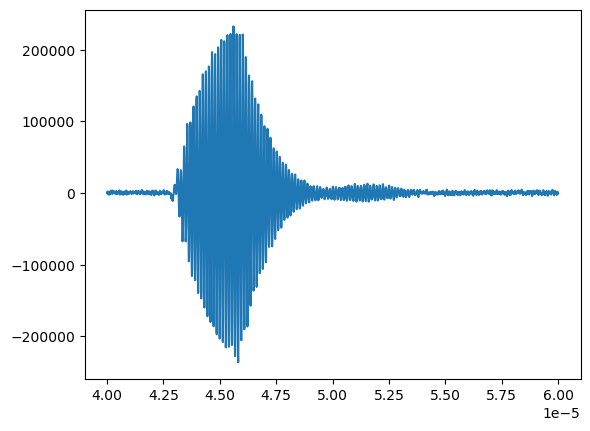

In [6]:
import matplotlib.pyplot as plt
plt.plot(time_s, pressure_pa[6,6,:])
plt.show()

## Intensity per grid point: cumulative-energy definitions

Plane-wave estimate: `I(t) = p(t)²/(ρc)`. The defaults are water at 20 °C: density 998 kg/m³ and sound speed 1482 m/s. 

The pulse gate must contain one complete pulse and its tails; use `pulse_gate_s` to exclude other pulses or unwanted noise. The default is a common 42–52 µs pulse gate, based on the observed focus pulse. It must be checked across the scan. A 40.05–42 µs pre-pulse window estimates a per-point baseline mean and noise variance. The baseline mean is removed for intensity calculations, and expected noise energy is subtracted by default. This assumes stationary additive noise; it does not remove coherent pulse-synchronous interference. 
Check the gate and capture coverage before reporting results.

Compute cumulative intensity within the gate. `PD = 1.25 × (t90 − t10)` uses fractions of the full gated pulse integral. `no_cycles / frequency` is retained as nominal duration for comparison, not used to define PD. Quantile times are calculated by inverting the trapezoidal cumulative energy curve with sub-sample accuracy.

The full-pulse power (PII) is the integral over the whole pulse waveform. Also report `PII_98` from t1 to t99 (98% of gated energy). Choose `pii_convention = "full_pulse"` (default) or `"central_98_percent"` explicitly; the latter is a truncated integral, not the full-pulse definition. PD remains based on the full gated cumulative energy in either mode.

`I_PA = selected_PII / PD`; repeating-train `I_TA = selected_PII × PRF`. Finite-exposure average `N × selected_PII / T_average` is reported separately. Averaging over `N/PRF` seconds includes the final silent interval and makes these temporal averages agree. Pulses are assumed identical; the square of an averaged waveform omits pulse-to-pulse variance.

Units: J/m² → mJ/cm²: divide by 10; W/m² → W/cm²: divide by 10,000.

Above calculations are based on the IEC-62359 standard:

[1. FDA pulse duration and PII definitions](https://digirepo.nlm.nih.gov/master/borndig/101760255/download.pdf), 

[2. IEC PII definition](https://preview.sist.si/sist-preview/23149/f252e6eb492c4998acafc18d2b5d17bf/IEC-62359-2010-AMD1-2017.pdf).

After noise subtraction, `p² − variance` can be negative locally. We retain signed integrals and avoid clipping every sample, which would introduce positive bias. For energy quantiles only, isotonic regression constructs a nondecreasing cumulative-energy estimate with fixed endpoints. This is a documented statistical estimator, not an IEC-prescribed noise-removal method. Its maximum adjustment is reported. Baseline uncertainty, temporal correlation and cross terms remain.

A user-selected net-signal/noise-energy threshold of 3 masks unresolved PD and I_PA as NaN. Do not interpret masked values as zero intensity or force them to the focus duration. Full PII and I_TA estimates remain available with signal-quality flags; negative net PII is clipped only for nonnegative per-point displays, while spatial integration retains signed estimates. `PII_98` is unavailable where energy quantiles are unreliable.

In [7]:
# USER SETTINGS
no_cycles = 20  # Nominal excitation length; measured PD is energy-based.
no_pulses = 1
prf_hz = 1000.0  # USER INPUT, not recorded in the per-point CSV headers or metadata.
density_kg_m3 = 998.0
sound_speed_m_s = 1482.0
pulse_gate_s = (42e-6, 52e-6)  # Common pulse gate including the observed focus pulse and tails.
noise_window_s = (40.05e-6, 42e-6)  # Pre-pulse baseline; verify it is pulse-free at every point.
subtract_noise_energy = True
minimum_signal_to_noise_energy_ratio = 3.0  # Analysis threshold, not an IEC requirement.
pii_convention = "full_pulse"  # Or "central_98_percent".
averaging_duration_s = None  # None: no_pulses / prf_hz; otherwise finite exposure duration.

if not all(np.isfinite(x) and x > 0 for x in
           [no_cycles, no_pulses, prf_hz, density_kg_m3, sound_speed_m_s]):
    raise ValueError("Cycle count, pulse count, PRF, density and sound speed must be positive")
if int(no_pulses) != no_pulses:
    raise ValueError("no_pulses must be an integer")
if pii_convention not in {"full_pulse", "central_98_percent"}:
    raise ValueError("Unknown PII convention")
acoustic_impedance_pa_s_m = density_kg_m3 * sound_speed_m_s
nominal_pulse_duration_s = no_cycles / (measurement_frequency_mhz * 1e6)


def pulse_energy_metrics(pressure, times, impedance, gate=None,
                         noise_variance_pa2=0.0, subtract_noise=False, minimum_energy_snr=3.0):
    """Pulse energy with expected noise subtraction and optional quantile reliability mask.

    Signed cumulative energy is projected monotonically for quantiles only.
    No sample-by-sample clipping of p²-noise variance is performed.
    """
    from scipy.optimize import isotonic_regression
    pressure, times = np.asarray(pressure, float), np.asarray(times, float)
    if pressure.shape != times.shape or len(times) < 2 or not np.isfinite(pressure).all():
        raise ValueError("Expected a finite 1-D waveform and matching times")
    if not np.isfinite(times).all() or (np.diff(times) <= 0).any() or not np.isfinite(impedance) or impedance <= 0:
        raise ValueError("Invalid time axis or acoustic impedance")
    if not np.isfinite(noise_variance_pa2) or noise_variance_pa2 < 0:
        raise ValueError("Noise variance must be finite and nonnegative")
    start, end = (times[0], times[-1]) if gate is None else tuple(gate)
    if not np.isfinite([start, end]).all() or not times[0] <= start < end <= times[-1]:
        raise ValueError("Pulse gate must lie inside the acquired time interval")
    intensity = pressure ** 2 / impedance
    gated_time = np.r_[start, times[(times > start) & (times < end)], end]
    gated_intensity = np.interp(gated_time, times, intensity)
    raw_areas = 0.5 * (gated_intensity[:-1] + gated_intensity[1:]) * np.diff(gated_time)
    raw_cumulative = np.r_[0., np.cumsum(raw_areas)]
    noise_intensity = noise_variance_pa2 / impedance
    noise_energy = noise_intensity * (end - start)
    signed_net = float(raw_cumulative[-1] - noise_energy)
    energy_snr = signed_net / noise_energy if noise_energy > 0 else np.inf if raw_cumulative[-1] > 0 else 0.
    signed_cumulative = raw_cumulative - (noise_intensity * (gated_time - start) if subtract_noise else 0.)
    signed_total = float(signed_cumulative[-1])
    # Nonnegative per-point display estimate. Retain signed values for unbiased spatial sums.
    total = max(signed_total, 0.)
    reliable = bool(total > 0 and energy_snr >= minimum_energy_snr)
    result = dict(pii_full=total, pii_98=np.nan,
                  t01=np.nan, t10=np.nan, t90=np.nan, t99=np.nan, pd=np.nan,
                  gate_start=start, gate_end=end,
                  pii_raw=float(raw_cumulative[-1]), pii_signed=signed_total,
                  expected_noise_pii=noise_energy, energy_snr=energy_snr,
                  duration_reliable=float(reliable), cumulative_projection_change=np.nan)
    if not reliable:
        return result
    # Energy after subtraction is signed and need not increase monotonically.
    # Fit a nondecreasing cumulative curve, constrain it to [0,total], and pin its endpoints.
    cumulative = np.clip(isotonic_regression(signed_cumulative).x, 0., total)
    cumulative[0], cumulative[-1] = 0., total
    result["cumulative_projection_change"] = float(np.max(np.abs(cumulative - signed_cumulative)) / total)
    # Invert the projected cumulative curve; fractional sample timing is interpolated.
    targets = np.array([.01, .1, .9, .99]) * total
    segments = np.clip(np.searchsorted(cumulative, targets, side="right") - 1, 0, len(cumulative) - 2)
    fractions = (targets - cumulative[segments]) / (cumulative[segments + 1] - cumulative[segments])
    t01, t10, t90, t99 = gated_time[segments] + fractions * (gated_time[segments + 1] - gated_time[segments])
    result.update(pii_98=.98 * total, t01=t01, t10=t10, t90=t90, t99=t99,
                  pd=1.25 * (t90 - t10))
    return result


if not np.isfinite(minimum_signal_to_noise_energy_ratio) or minimum_signal_to_noise_energy_ratio <= 0:
    raise ValueError("Signal-to-noise energy threshold must be positive")
if not time_s[0] <= noise_window_s[0] < noise_window_s[1] <= time_s[-1]:
    raise ValueError("Baseline noise window must lie within the shared time axis")
noise_mask = (time_s >= noise_window_s[0]) & (time_s <= noise_window_s[1])
if noise_mask.sum() < 20:
    raise ValueError("Baseline window must contain at least 20 acquired samples")
if pulse_gate_s is not None and max(noise_window_s[0], pulse_gate_s[0]) < min(noise_window_s[1], pulse_gate_s[1]):
    raise ValueError("Noise and pulse windows must not overlap")
baseline_pressure_pa_map = np.mean(pressure_pa[..., noise_mask], axis=-1)
noise_variance_pa2_map = np.var(pressure_pa[..., noise_mask], axis=-1, ddof=1)
energy_pressure_pa = pressure_pa - baseline_pressure_pa_map[..., None]
# This waveform is baseline-centred; energy subtraction does not reconstruct a noise-free waveform.
instantaneous_intensity_w_m2 = energy_pressure_pa ** 2 / acoustic_impedance_pa_s_m
pulse_quantile_maps = {key: np.empty(pressure_pa.shape[:2]) for key in
                       ["pii_full", "pii_98", "t01", "t10", "t90", "t99", "pd", "gate_start", "gate_end",
                        "pii_raw", "pii_signed", "expected_noise_pii", "energy_snr", "duration_reliable",
                        "cumulative_projection_change"]}
for index in np.ndindex(pressure_pa.shape[:2]):
    result = pulse_energy_metrics(energy_pressure_pa[index], time_s, acoustic_impedance_pa_s_m, pulse_gate_s,
                                 noise_variance_pa2_map[index], subtract_noise_energy,
                                 minimum_signal_to_noise_energy_ratio)
    for key, value in result.items():
        pulse_quantile_maps[key][index] = value
pii_full_j_m2 = pulse_quantile_maps["pii_full"]
pii_98_j_m2 = pulse_quantile_maps["pii_98"]
pulse_intensity_integral_j_m2 = (pii_full_j_m2 if pii_convention == "full_pulse" else pii_98_j_m2)
pulse_duration_s_map = pulse_quantile_maps["pd"]
pulse_window_start_s_map = pulse_quantile_maps["gate_start"]
pulse_average_intensity_w_m2 = np.divide(
    pulse_intensity_integral_j_m2, pulse_duration_s_map,
    out=np.full_like(pulse_intensity_integral_j_m2, np.nan),
    where=np.isfinite(pulse_duration_s_map) & (pulse_duration_s_map > 0))
temporal_average_intensity_w_m2 = pulse_intensity_integral_j_m2 * prf_hz
if np.nanmax(pulse_duration_s_map) * prf_hz > 1:
    raise ValueError("Measured pulse duration exceeds the repetition period")
temporal_averaging_duration_s = (no_pulses / prf_hz if averaging_duration_s is None
                                else float(averaging_duration_s))
minimum_exposure_s = (no_pulses - 1) / prf_hz + np.nanmax(pulse_duration_s_map)
if not np.isfinite(temporal_averaging_duration_s) or temporal_averaging_duration_s < minimum_exposure_s:
    raise ValueError("Averaging duration must cover the requested pulse train")
finite_exposure_average_intensity_w_m2 = (no_pulses * pulse_intensity_integral_j_m2
                                        / temporal_averaging_duration_s)
intensity_maps = {
    "pulse-average intensity": pulse_average_intensity_w_m2 / 1e4,
    "temporal-average intensity": temporal_average_intensity_w_m2 / 1e4,
}
print(f"Impedance: {acoustic_impedance_pa_s_m:,.0f} Pa·s/m")
print(f"Nominal pulse duration: {nominal_pulse_duration_s * 1e6:.6f} µs")
print(f"Measured PD range: {np.nanmin(pulse_duration_s_map)*1e6:.6f}–{np.nanmax(pulse_duration_s_map)*1e6:.6f} µs")
print(f"PII convention: {pii_convention}; PRF: {prf_hz:g} Hz")
print(f"Reliable pulse durations: {int(pulse_quantile_maps['duration_reliable'].sum())}/{point_id_grid.size}")
print(f"Median reliable PD: {np.nanmedian(pulse_duration_s_map)*1e6:.6f} µs")

Impedance: 1,479,036 Pa·s/m
Nominal pulse duration: 2.713704 µs
Measured PD range: 2.727047–8.769522 µs
PII convention: full_pulse; PRF: 1000 Hz
Reliable pulse durations: 60/144
Median reliable PD: 4.431313 µs


## Interactive field map

The metric and colormap dropdowns operate independently. The figure uses fixed pixel dimensions and margins; edit `figure_width_px` and `figure_height_px` to resize it.

Grayscale (8-bit) and (16-bit) round the displayed normalized values to 256 and 65,536 levels, respectively, over each metric's range. Calculated arrays and hover values retain full precision. These options control the display, not the bit depth of an exported image; visible shades depend on the browser and monitor.

The third dropdown switches physical units to `quantity / max(quantity)` over the spatial map. Normalized labels are dimensionless; hover shows both normalized and original values. This uses the signed maximum (not maximum absolute magnitude). All-zero maps remain zero; a zero maximum with nonzero values makes normalization undefined. The same scaling applies independently to every metric and is preserved when switching metrics or palettes.

In [8]:
import plotly.graph_objects as go
import matplotlib as mpl

# Display pressure metrics in kPa; preserve source arrays and metrics_df in Pa.
pressure_metrics = {"max", "min", "rms", "standard deviation"}
display_metric_maps = {name: values / 1000 if name in pressure_metrics else values
                       for name, values in metric_maps.items()}
display_metric_units = {name: "kPa" if name in pressure_metrics else unit
                        for name, unit in metric_units.items()}

# Fixed canvas and margins keep the plot area stable when metrics change.
figure_width_px = 900
figure_height_px = 800
metric_maps.update(intensity_maps)
metric_units.update({metric: "W/cm²" for metric in intensity_maps})
plot_metrics = [*statistical_metrics, *intensity_maps]
for metric, values in intensity_maps.items():
    metrics_df[metric] = metrics_df["point_order"].map(
        dict(zip(point_id_grid.ravel(), values.ravel())))


def quantize_display(values, bits):
    """Quantize display values; preserve NaNs and the original metric array."""
    result = values.copy()
    finite = np.isfinite(values)
    if not finite.any():
        return result
    low, high = values[finite].min(), values[finite].max()
    if high > low:
        levels = 2 ** bits - 1
        result[finite] = low + np.round((values[finite] - low) / (high - low) * levels) / levels * (high - low)
    return result


def normalize_by_max(values):
    """Divide by the signed spatial maximum; preserve NaNs and all-zero maps."""
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    if not finite.any():
        return values.copy(), np.nan
    maximum = float(values[finite].max())
    if maximum == 0:
        if np.any(values[finite] != 0):
            return np.full_like(values, np.nan), maximum
        return values.copy(), maximum
    return values / maximum, maximum


# Dividing a map and its color limits by the same positive maximum leaves its
# colors unchanged. Keep rendering in physical coordinates so normalization and
# colormap dropdowns remain independent; switch colorbar labels and hover values.
# Negative maxima retain the signed definition q/max(q), not max(abs(q)).
display_metric_maps.update(intensity_maps)
display_metric_units.update({name: "W/cm²" for name in intensity_maps})
original_display_maps = [display_metric_maps[metric].T.copy() for metric in plot_metrics]
normalized_display_maps = [normalize_by_max(values)[0] for values in original_display_maps]
raw_hover_templates, normalized_hover_templates = [], []
raw_colorbar_labels, normalized_colorbar_labels = [], []
raw_colorbar_titles, normalized_colorbar_titles = [], []
fig_pressure_map = go.Figure()
for index, metric in enumerate(plot_metrics):
    unit = display_metric_units[metric]
    original = original_display_maps[index]
    finite = original[np.isfinite(original)]
    limits = dict(zmin=float(finite.min()), zmax=float(finite.max())) if finite.size else {}
    ticks = np.linspace(float(finite.min()), float(finite.max()), 5) if finite.size else np.array([])
    maximum = normalize_by_max(original)[1]
    tick_normalized = (ticks / maximum if np.isfinite(maximum) and maximum != 0 else
                       np.zeros_like(ticks) if finite.size and np.all(finite == 0) else
                       np.full_like(ticks, np.nan))
    raw_colorbar_labels.append([f"{value:.2e}" for value in ticks])
    normalized_colorbar_labels.append([f"{value:.2e}" if np.isfinite(value) else "undefined" for value in tick_normalized])
    raw_colorbar_titles.append(f"{metric} ({unit})")
    normalized_colorbar_titles.append(f"{metric} / max ({'dimensionless'})")
    fig_pressure_map.add_trace(go.Heatmap(
        x=axis1_mm, y=axis2_mm, z=original,
        customdata=np.stack([point_id_grid.T, original, normalized_display_maps[index]], axis=-1),
        visible=index == 0, name=metric, colorscale="Viridis", **limits,
        colorbar=dict(
            title=dict(text=f"{metric} ({unit})", side="right"),
            x=0.918, xanchor="left", y=0.5, len=1, xpad=0, ypad=0,
            thickness=18, thicknessmode="pixels", tickformat=".2e",
            tickfont=dict(size=13), outlinewidth=0.7,
            tickmode="array", tickvals=ticks, ticktext=raw_colorbar_labels[-1],
        ),
        hovertemplate=(f"{axis1_name}: %{{x:.4f}} mm<br>"
                       f"{axis2_name}: %{{y:.4f}} mm<br>"
                       "Point: %{customdata[0]:.0f}<br>"
                       f"{metric}: %{{customdata[1]:.6g}} {unit}<extra></extra>"),
    ))

    raw_hover_templates.append(fig_pressure_map.data[-1].hovertemplate)
    normalized_hover_templates.append(
        fig_pressure_map.data[-1].hovertemplate.replace(
            f"{metric}: %{{customdata[1]:.6g}} {unit}",
            f"{metric} / max: %{{customdata[2]:.6g}} (dimensionless)<br>"
            f"Original: %{{customdata[1]:.6g}} {unit}"))

normalization_buttons = [
    dict(label="Physical units", method="restyle", args=[{
        "colorbar.ticktext": raw_colorbar_labels,
        "colorbar.title.text": raw_colorbar_titles,
        "hovertemplate": raw_hover_templates,
    }]),
    dict(label="Normalize by max", method="restyle", args=[{
        "colorbar.ticktext": normalized_colorbar_labels,
        "colorbar.title.text": normalized_colorbar_titles,
        "hovertemplate": normalized_hover_templates,
    }]),
]

metric_buttons = [dict(
    label=metric, method="update",
    args=[{"visible": [i == index for i in range(len(plot_metrics))]},
          {"title.text": f"Pressure field — {metric}"}],
) for index, metric in enumerate(plot_metrics)]

# Apply the colormap to every trace so both dropdown selections remain independent.
# Grayscale quantization affects rendering only, not metric_maps or hover values.
colormap_options = {
    "Viridis": ("Viridis", None),
    "Grayscale (8-bit)": ("Greys", 8),
    "Grayscale (16-bit)": ("Greys", 16),
    "Plasma": ("Plasma", None),
    "Inferno": ("Inferno", None),
    "Magma": ("Magma", None),
    "Cividis": ("Cividis", None),
    "Turbo": ("Turbo", None),
    "RdBu": ("RdBu", None),
}
# Use Matplotlib definitions for the requested palettes.
def matplotlib_colorscale(name):
    cmap = mpl.colormaps[name]
    if name in {"Paired", "tab20"}:
        # Paired is capitalized in Matplotlib; keep categorical color bands discrete.
        stops = []
        for i in range(cmap.N):
            color = mpl.colors.to_hex(cmap(i))
            stops.extend([[i / cmap.N, color], [(i + 1) / cmap.N, color]])
        return stops
    return [[i / 255, mpl.colors.to_hex(cmap(i / 255))] for i in range(256)]

for name in ["seismic", "coolwarm", "spectral", "jet", "hsv", "prism", "paired", "tab20"]:
    mpl_name = {"spectral": "Spectral", "paired": "Paired"}.get(name, name)
    colormap_options[name] = (matplotlib_colorscale(mpl_name), None)
colormap_buttons = []
for label, (scale, bits) in colormap_options.items():
    displayed = (original_display_maps if bits is None else
                 [quantize_display(values, bits) for values in original_display_maps])
    # Explicit black-to-white grayscale; scientific maps use Plotly's named palettes.
    colorscale = [[0, "black"], [1, "white"]] if bits is not None else scale
    colormap_buttons.append(dict(
        label=label, method="restyle",
        args=[{"colorscale": [colorscale] * len(plot_metrics), "z": displayed}],
    ))

fig_pressure_map.update_layout(
    title=dict(text=f"Pressure field — {plot_metrics[0]}", x=0.08, y=0.98),
    template="plotly_white", width=figure_width_px, height=figure_height_px,
    font=dict(family="Arial", size=15, color="black"),
    paper_bgcolor="white", plot_bgcolor="white",
    autosize=False,
    xaxis=dict(title=f"Scan axis 1: {axis1_name} (mm)", automargin=False,
               domain=[0, 605 / 670], constrain="domain",
               showline=True, mirror=True, ticks="outside", showgrid=False),
    yaxis=dict(title=f"Scan axis 2: {axis2_name} (mm)", automargin=False,
               scaleanchor="x", scaleratio=1, constrain="domain",
               showline=True, mirror=True, ticks="outside", showgrid=False),
    margin=dict(l=85, r=145, t=110, b=85, autoexpand=False),
    updatemenus=[
        dict(buttons=metric_buttons, direction="down", x=0.36, y=1.15,
             xanchor="right", yanchor="top", active=0),
        dict(buttons=colormap_buttons, direction="down", x=0.64, y=1.15,
             xanchor="right", yanchor="top", active=0),
        dict(buttons=normalization_buttons, direction="down", x=1.0, y=1.15,
             xanchor="right", yanchor="top", active=0),
    ],
)
fig_pressure_map.show(config={
    "responsive": False,
    "toImageButtonOptions": {"format": "png", "filename": "pressure_field",
                             "width": figure_width_px, "height": figure_height_px, "scale": 4},
})

## Aperture correction and systematic intensity report

The cells below implement the quadratic, near-axis scan method associated with IEC 62127-1:2007 + Amendment 1:2013 Annex E, using `K = (3 − β)/2`. IEC 62127-1:2022 revised the spatial-averaging procedures. It estimates corrections to **spatial peak quantities**, not a deconvolution of every pixel or the complete waveform.

**Aperture.** Onda lists the HGL-0400 electrode diameter as 400 µm, giving a geometrical radius of 0.2 mm. We assume this equals the effective sensitive radius at the measurement frequency unless `effective_aperture_diameter_um` is supplied. Electrode diameter alone does not establish the frequency-dependent effective aperture.

**Method.** For each quantity separately, find its sampled spatial peak and evaluate its spatial profile at ± one effective radius along both scan axes. Average the four off-axis/on-axis ratios to obtain β. This averages the two perpendicular directions and both sides. Derive separate factors for peak compressional pressure, peak rarefactional magnitude, and `sqrt(∫pulse p² dt)`. Intensity corrections use the **square of the latter factor**, not the peak-pressure factor. The approximation assumes a circular uniformly sensitive aperture, a locally quadratic beam profile, negligible phase variation, and linear/quasilinear propagation. No broadband nonlinear harmonic correction is done as we used a relatively long pulse (> 20 cycles) for these measurements. For short pulses we need to do multiple/broadband-frequency calibration.

**Resolution limitation.** This scan's 0.364 mm spacing exceeds the 0.2 mm radius. Linear interpolation at the required offsets gives a provisional estimate, not new measured spatial information. Peak location can also lie between grid points. Acquire finer scans through the actual peak at radius-sized or smaller offsets.

**Intensity convention.** `PII = ∫pulse p²dt/(ρc)`; `I_PA = PII/PD`; `I_TA = N × PII/T_average`; `PD = 1.25 × (t90 − t10)`. Existing per-pixel pulse windows and user settings are reused. Reported I_SPPA and I_SPTA are spatial maxima, which are not necessarily at the compressional-pressure peak. The reconstructed identical-pulse train assumes the recorded averaged waveform represents each pulse; pulse-to-pulse variance is unavailable.

References: [Onda HGL specifications](https://www.ondacorp.com/capsule-hydrophone/), [primary derivation, equations 23–25](https://pmc.ncbi.nlm.nih.gov/articles/PMC6935508/), [experimental assessment of Annex E corrections](https://pmc.ncbi.nlm.nih.gov/articles/PMC5639436/), [IEC 2022 revision](https://webstore.iec.ch/en/publication/75130).

When measured PD varies spatially, I_SPPA need not peak at the PII peak. A separate quadratic near-axis factor is therefore evaluated from `sqrt(I_PA)` for the pulse-average peak. This is an additional model estimate, not a full waveform deconvolution; temporal-average correction uses `sqrt(PII)`. A common scalar waveform correction would leave the energy-quantile PD unchanged.

Noise handling update: the pulse-average peak fit omits unresolved pixels (represented as zero only in the temporary fit-input map); neighbouring required offsets must have reliable PD or its correction is withheld. This avoids treating a masked pixel as a measured zero.

In [9]:
# USER SETTINGS: spatial averaging correction.
electrode_aperture_diameter_um = 400.0
effective_aperture_diameter_um = None  # Supply a measured effective diameter at this frequency if available.
allow_interpolated_aperture_estimate = True  # False: require scans with spacing <= effective radius.

# Optional independently measured off-axis/on-axis ratios, at ±radius on each axis.
# Quantity-specific measurements must correspond to each quantity's true spatial peak.
# Example structure: {"compressional pressure": [beta_x_minus, beta_x_plus, beta_y_minus, beta_y_plus]}
measured_aperture_ratios = {}
# Supported keys include "sqrt pulse-average intensity" and: "compressional pressure", "rarefactional pressure", "sqrt pulse-pressure-squared integral".

aperture_diameter_um = (electrode_aperture_diameter_um if effective_aperture_diameter_um is None
                        else float(effective_aperture_diameter_um))
if not np.isfinite(aperture_diameter_um) or aperture_diameter_um <= 0:
    raise ValueError("Aperture diameter must be finite and positive")
effective_radius_mm = aperture_diameter_um / 2000.0
print(f"Assumed effective radius: {effective_radius_mm:.6g} mm")

Assumed effective radius: 0.2 mm


In [10]:
def annex_e_peak_estimate(signal_map, axis1, axis2, radius_mm,
                          measured_ratios=None, allow_interpolation=True):
    """Near-axis quadratic correction for a nonnegative pressure-like quantity.

    Returns a spatial-peak estimate only; no correction is applied off-axis.
    """
    values = np.asarray(signal_map, dtype=float)
    axis1, axis2 = np.asarray(axis1, dtype=float), np.asarray(axis2, dtype=float)
    if values.shape != (len(axis1), len(axis2)) or not np.isfinite(values).all() or (values < 0).any():
        raise ValueError("Expected a finite nonnegative map matching the scan axes")
    if not np.isfinite(radius_mm) or radius_mm <= 0:
        raise ValueError("Radius must be finite and positive")
    if len(axis1) < 2 or len(axis2) < 2 or (np.diff(axis1) <= 0).any() or (np.diff(axis2) <= 0).any():
        raise ValueError("Two increasing spatial axes are required")
    i, j = np.unravel_index(np.argmax(values), values.shape)
    peak = float(values[i, j])
    coarse = bool(max(np.diff(axis1).max(), np.diff(axis2).max()) > radius_mm)
    result = {"axis1_index": int(i), "axis2_index": int(j),
              "axis1_mm": float(axis1[i]), "axis2_mm": float(axis2[j]),
              "measured_peak": peak, "radius_mm": radius_mm,
              "scan_coarser_than_radius": coarse,
              "effective_diameter_assumed": effective_aperture_diameter_um is None}
    if peak == 0:
        return {**result, "beta": np.nan, "pressure_factor": 1.0,
                "corrected_peak": 0.0, "status": "zero signal", "source": "none"}
    if measured_ratios is None and np.all(values == peak):
        return {**result, "beta": 1.0, "pressure_factor": 1.0,
                "corrected_peak": peak, "status": "uniform sampled field; no estimated correction",
                "source": "uniform sampled profile"}
    if measured_ratios is not None:
        ratios = np.asarray(measured_ratios, dtype=float)
        if ratios.shape != (4,) or not np.isfinite(ratios).all() or (ratios <= 0).any() or (ratios > 1).any():
            raise ValueError("Supply four ratios in (0, 1], measured around the quantity's peak")
        source = "user-supplied measurements"
    else:
        if coarse and not allow_interpolation:
            raise ValueError("Scan spacing exceeds hydrophone radius; acquire a finer scan or supply measured ratios")
        x, y = axis1[i], axis2[j]
        if x - radius_mm < axis1[0] or x + radius_mm > axis1[-1] or y - radius_mm < axis2[0] or y + radius_mm > axis2[-1]:
            return {**result, "beta": np.nan, "pressure_factor": np.nan,
                    "corrected_peak": np.nan, "status": "insufficient spatial coverage", "source": "none"}
        ratios = np.r_[np.interp([x - radius_mm, x + radius_mm], axis1, values[:, j]),
                       np.interp([y - radius_mm, y + radius_mm], axis2, values[i, :])] / peak
        source = "interpolated scan profile"
    beta = float(ratios.mean())
    factor = (3.0 - beta) / 2.0
    drops_db = -20 * np.log10(np.maximum(ratios, np.finfo(float).tiny))
    status = "quadratic-model estimate"
    if measured_ratios is None and coarse:
        status = "provisional: coarse scan interpolation"
    if (ratios <= 0).any() or (ratios > 1).any():
        status = "invalid off-axis ratios"
        factor = np.nan
    return {**result, "beta": beta, "pressure_factor": factor,
            "corrected_peak": peak * factor, "status": status, "source": source,
            "beta_axis1_minus": ratios[0], "beta_axis1_plus": ratios[1],
            "beta_axis2_minus": ratios[2], "beta_axis2_plus": ratios[3],
            "max_off_axis_drop_db": float(drops_db.max()),
            "off_axis_drop_exceeds_1db": bool((drops_db > 1).any())}


# Use the same pulse windows as the intensity calculation above.
# Squared-pressure integral = PII * characteristic acoustic impedance.
pulse_pressure_squared_integral_pa2_s = (pulse_intensity_integral_j_m2
                                        * density_kg_m3 * sound_speed_m_s)
compressional_pressure_pa_map = np.maximum(np.max(pressure_pa, axis=-1), 0)
rarefactional_pressure_pa_map = np.maximum(-np.min(pressure_pa, axis=-1), 0)
aperture_signal_maps = {
    "compressional pressure": compressional_pressure_pa_map,
    "rarefactional pressure": rarefactional_pressure_pa_map,
    "sqrt pulse-pressure-squared integral": np.sqrt(pulse_pressure_squared_integral_pa2_s),
    "sqrt pulse-average intensity": np.sqrt(np.nan_to_num(pulse_average_intensity_w_m2, nan=0.0)),
}
unknown_keys = set(measured_aperture_ratios) - set(aperture_signal_maps)
if unknown_keys:
    raise ValueError(f"Unknown measured-ratio quantities: {sorted(unknown_keys)}")
aperture_results = {}
for quantity, values in aperture_signal_maps.items():
    aperture_results[quantity] = annex_e_peak_estimate(
        values, axis1_mm, axis2_mm, effective_radius_mm,
        measured_ratios=measured_aperture_ratios.get(quantity),
        allow_interpolation=allow_interpolated_aperture_estimate)
aperture_correction_df = pd.DataFrame.from_dict(aperture_results, orient="index")
aperture_correction_df.index.name = "quantity"
display(aperture_correction_df)

intensity_pressure_factor = aperture_results["sqrt pulse-pressure-squared integral"]["pressure_factor"]
intensity_correction_factor = intensity_pressure_factor ** 2
corrected_peak_compressional_pressure_pa = aperture_results["compressional pressure"]["corrected_peak"]
corrected_peak_rarefactional_pressure_pa = aperture_results["rarefactional pressure"]["corrected_peak"]
# Only spatial peaks are corrected; applying a peak factor to the whole map would be unjustified.
pulse_average_intensity_correction_factor = aperture_results["sqrt pulse-average intensity"]["pressure_factor"] ** 2
corrected_isppa_w_m2 = float(np.nanmax(pulse_average_intensity_w_m2)) * pulse_average_intensity_correction_factor
corrected_ispta_w_m2 = float(np.max(temporal_average_intensity_w_m2)) * intensity_correction_factor
pa_result = aperture_results["sqrt pulse-average intensity"]
pa_i, pa_j = pa_result["axis1_index"], pa_result["axis2_index"]
required_support = {(pa_i, pa_j)}
for coordinate in [axis1_mm[pa_i] - effective_radius_mm, axis1_mm[pa_i] + effective_radius_mm]:
    k = int(np.searchsorted(axis1_mm, coordinate))
    required_support.update((i, pa_j) for i in [max(0, k-1), min(len(axis1_mm)-1, k)])
for coordinate in [axis2_mm[pa_j] - effective_radius_mm, axis2_mm[pa_j] + effective_radius_mm]:
    k = int(np.searchsorted(axis2_mm, coordinate))
    required_support.update((pa_i, j) for j in [max(0, k-1), min(len(axis2_mm)-1, k)])
if "sqrt pulse-average intensity" not in measured_aperture_ratios and not all(np.isfinite(pulse_duration_s_map[index]) for index in required_support):
    pa_result.update(pressure_factor=np.nan, corrected_peak=np.nan,
                     status="withheld: unresolved PD in required off-axis support")
    pulse_average_intensity_correction_factor = np.nan
    corrected_isppa_w_m2 = np.nan
    aperture_correction_df = pd.DataFrame.from_dict(aperture_results, orient="index")
    aperture_correction_df.index.name = "quantity"


,axis1_index,axis2_index,axis1_mm,axis2_mm,measured_peak,radius_mm,scan_coarser_than_radius,effective_diameter_assumed,beta,pressure_factor,corrected_peak,status,source,beta_axis1_minus,beta_axis1_plus,beta_axis2_minus,beta_axis2_plus,max_off_axis_drop_db,off_axis_drop_exceeds_1db
quantity,,,,,,,,,,,,,,,,,,,
compressional pressure,6,6,2.181818,2.181818,232506.028067,0.2,True,True,0.609435,1.195282,277910.356069,provisional: coarse scan interpolation,interpolated scan profile,0.628130,0.635506,0.571597,0.602508,4.858198,True
rarefactional pressure,6,6,2.181818,2.181818,236402.213986,0.2,True,True,0.613810,1.193095,282050.248738,provisional: coarse scan interpolation,interpolated scan profile,0.644827,0.632603,0.572269,0.605543,4.847993,True
sqrt pulse-pressure-squared integral,6,6,2.181818,2.181818,240.393091,0.2,True,True,0.613716,1.193142,286.823125,provisional: coarse scan interpolation,interpolated scan profile,0.649589,0.629312,0.575222,0.600741,4.803293,True
sqrt pulse-average intensity,6,6,2.181818,2.181818,115.995990,0.2,True,True,0.599771,1.200114,139.208455,provisional: coarse scan interpolation,interpolated scan profile,0.607388,0.619711,0.570630,0.601356,4.872913,True


In [11]:
# Systematic per-point report of measured pressure and intensity quantities.
# Correction factors are reported separately for spatial peaks, not applied to every pixel.
intensity_point_report_df = pd.DataFrame({
    "point_order": point_id_grid.ravel(),
    "axis1_mm": a1_grid.ravel(), "axis2_mm": a2_grid.ravel(),
    "peak_compressional_kpa": compressional_pressure_pa_map.ravel() / 1000,
    "peak_rarefactional_magnitude_kpa": rarefactional_pressure_pa_map.ravel() / 1000,
    "pulse_start_time_s": pulse_window_start_s_map.ravel(),
    "pulse_duration_s": pulse_duration_s_map.ravel(),
    "nominal_pulse_duration_s": nominal_pulse_duration_s,
    "t01_s": pulse_quantile_maps["t01"].ravel(), "t10_s": pulse_quantile_maps["t10"].ravel(),
    "t90_s": pulse_quantile_maps["t90"].ravel(), "t99_s": pulse_quantile_maps["t99"].ravel(),
    "pii_full_j_m2": pii_full_j_m2.ravel(), "pii_98_j_m2": pii_98_j_m2.ravel(),
    "selected_pii_mj_cm2": pulse_intensity_integral_j_m2.ravel() / 10,
    "pii_convention": pii_convention,
    "noise_variance_pa2": noise_variance_pa2_map.ravel(),
    "expected_noise_pii_j_m2": pulse_quantile_maps["expected_noise_pii"].ravel(),
    "pii_raw_j_m2": pulse_quantile_maps["pii_raw"].ravel(),
    "pii_signed_j_m2": pulse_quantile_maps["pii_signed"].ravel(),
    "signal_to_noise_energy_ratio": pulse_quantile_maps["energy_snr"].ravel(),
    "duration_reliable": pulse_quantile_maps["duration_reliable"].ravel().astype(bool),
    "cumulative_projection_change_fraction": pulse_quantile_maps["cumulative_projection_change"].ravel(),
    "finite_exposure_average_intensity_w_cm2": finite_exposure_average_intensity_w_m2.ravel() / 1e4,
    "pulse_pressure_squared_integral_pa2_s": pulse_pressure_squared_integral_pa2_s.ravel(),
    "pulse_intensity_integral_j_m2": pulse_intensity_integral_j_m2.ravel(),
    "pulse_average_intensity_w_cm2": pulse_average_intensity_w_m2.ravel() / 1e4,
    "temporal_average_intensity_w_cm2": temporal_average_intensity_w_m2.ravel() / 1e4,
    "no_cycles": no_cycles, "no_pulses": no_pulses,
    "prf_hz": prf_hz, "averaging_duration_s": temporal_averaging_duration_s,
    "frequency_mhz": measurement_frequency_mhz,
    "density_kg_m3": density_kg_m3, "sound_speed_m_s": sound_speed_m_s,
    "sensitivity_v_per_pa": sensitivity_v_per_pa,
}).sort_values("point_order").reset_index(drop=True)

spatial_peak_report_df = pd.DataFrame([
    {"quantity": "peak compressional pressure", "unit": "kPa",
     "measured": compressional_pressure_pa_map.max() / 1000,
     "aperture_corrected_estimate": corrected_peak_compressional_pressure_pa / 1000,
     "correction_factor": aperture_results["compressional pressure"]["pressure_factor"],
     "status": aperture_results["compressional pressure"]["status"]},
    {"quantity": "peak rarefactional magnitude", "unit": "kPa",
     "measured": rarefactional_pressure_pa_map.max() / 1000,
     "aperture_corrected_estimate": corrected_peak_rarefactional_pressure_pa / 1000,
     "correction_factor": aperture_results["rarefactional pressure"]["pressure_factor"],
     "status": aperture_results["rarefactional pressure"]["status"]},
    {"quantity": "I_SPPA", "unit": "W/cm²",
     "measured": np.nanmax(pulse_average_intensity_w_m2) / 1e4,
     "aperture_corrected_estimate": corrected_isppa_w_m2 / 1e4,
     "correction_factor": pulse_average_intensity_correction_factor,
     "status": aperture_results["sqrt pulse-average intensity"]["status"]},
    {"quantity": "I_SPTA", "unit": "W/cm²",
     "measured": temporal_average_intensity_w_m2.max() / 1e4,
     "aperture_corrected_estimate": corrected_ispta_w_m2 / 1e4,
     "correction_factor": intensity_correction_factor,
     "status": aperture_results["sqrt pulse-pressure-squared integral"]["status"]},
])
display(spatial_peak_report_df)
display(intensity_point_report_df.head())

# Explicitly distinguish measured heatmaps from corrected peak estimates.
# Optional reproducible CSV export:
export_correction_reports = False
if export_correction_reports:
    report_dir = project_root / "figures" / "pressure_field"
    report_dir.mkdir(parents=True, exist_ok=True)
    aperture_correction_df.to_csv(report_dir / "aperture_correction_diagnostics.csv")
    intensity_point_report_df.to_csv(report_dir / "intensity_per_point.csv", index=False)
    spatial_peak_report_df.to_csv(report_dir / "spatial_peak_aperture_estimates.csv", index=False)

,quantity,unit,measured,aperture_corrected_estimate,correction_factor,status
0,peak compressional pressure,kPa,232.506028,277.910356,1.195282,provisional: coarse scan interpolation
1,peak rarefactional magnitude,kPa,236.402214,282.050249,1.193095,provisional: coarse scan interpolation
2,I_SPPA,W/cm²,1.345507,1.937899,1.440275,provisional: coarse scan interpolation
3,I_SPTA,W/cm²,0.003907,0.005562,1.423588,provisional: coarse scan interpolation


,point_order,axis1_mm,axis2_mm,peak_compressional_kpa,peak_rarefactional_magnitude_kpa,pulse_start_time_s,pulse_duration_s,nominal_pulse_duration_s,t01_s,t10_s,...,pulse_average_intensity_w_cm2,temporal_average_intensity_w_cm2,no_cycles,no_pulses,prf_hz,averaging_duration_s,frequency_mhz,density_kg_m3,sound_speed_m_s,sensitivity_v_per_pa
0,1,0.000000,0.0,6.069225,5.590189,0.000042,NaN,0.000003,NaN,NaN,...,NaN,5.724346e-07,20,1,1000.0,0.001,7.37,998.0,1482.0,0.000003
1,2,0.363636,0.0,5.802953,6.376964,0.000042,NaN,0.000003,NaN,NaN,...,NaN,8.949674e-07,20,1,1000.0,0.001,7.37,998.0,1482.0,0.000003
2,3,0.727273,0.0,4.988751,5.363439,0.000042,NaN,0.000003,NaN,NaN,...,NaN,1.751747e-07,20,1,1000.0,0.001,7.37,998.0,1482.0,0.000003
3,4,1.090909,0.0,6.278031,5.905678,0.000042,NaN,0.000003,NaN,NaN,...,NaN,1.148910e-06,20,1,1000.0,0.001,7.37,998.0,1482.0,0.000003
4,5,1.454545,0.0,8.087442,7.502131,0.000042,NaN,0.000003,NaN,NaN,...,NaN,2.421885e-06,20,1,1000.0,0.001,7.37,998.0,1482.0,0.000003


## Scan-area acoustic pulse energy and power

Integrate the **gated full-pulse PII estimate**, using signed noise-subtracted values when subtraction is enabled over the scanned rectangle using nested trapezoidal quadrature on the actual coordinates in metres. This avoids counting edge nodes as complete cells. It estimates energy crossing this finite scan area, not necessarily the transducer's total pulse energy. Power is `E_pulse × PRF` for a stationary repeating beam; finite-exposure power is `N × E_pulse / T_average`.

This should only be used as a transverse energy estimate if the scan plane is perpendicular to the beam. Set the propagation axis below. Aperture corrections derived at the spatial peak are **not** applied globally to the area integral.

Report λ/2 spacing, boundary PII relative to the peak, and fundamental temporal sampling. if boundary values are too small, all sidelobes cannot be captured. 
If pulses are short or nonlniear, the broadband sampling adequacy requires the highest significant frequency, not just the fundamental.

In [12]:
# USER SETTINGS / acquisition facts to verify.
beam_propagation_axis = "X"  # normal to the transverse Y–Z plane here.
highest_significant_frequency_mhz = None  # Supply after checking the waveform spectrum.
boundary_peak_fraction_threshold = 0.01


def integrate_scan_area(values, axis1_m, axis2_m):
    values = np.asarray(values, float)
    axis1_m, axis2_m = np.asarray(axis1_m, float), np.asarray(axis2_m, float)
    if values.shape != (len(axis1_m), len(axis2_m)):
        raise ValueError("Map shape does not match scan axes")
    # Trapezoidal weights over the rectangle bounded by coordinate centres.
    along_axis2 = np.sum(0.5 * (values[:, :-1] + values[:, 1:]) * np.diff(axis2_m), axis=1)
    return float(np.sum(0.5 * (along_axis2[:-1] + along_axis2[1:]) * np.diff(axis1_m)))


transverse_plane_assumed = beam_propagation_axis not in {axis1_name, axis2_name}
if not transverse_plane_assumed:
    raise ValueError("Scan plane contains the beam axis; cannot interpret this integral as transverse pulse energy")
scan_area_integration_pii_j_m2 = pulse_quantile_maps["pii_signed"] if subtract_noise_energy else pii_full_j_m2
scan_area_pulse_energy_j = integrate_scan_area(scan_area_integration_pii_j_m2, axis1_mm * 1e-3, axis2_mm * 1e-3)
scan_area_time_average_power_w = scan_area_pulse_energy_j * prf_hz
scan_area_finite_exposure_power_w = no_pulses * scan_area_pulse_energy_j / temporal_averaging_duration_s
wavelength_mm = sound_speed_m_s / (measurement_frequency_mhz * 1e6) * 1000
max_step_axis1_mm = float(np.diff(axis1_mm).max())
max_step_axis2_mm = float(np.diff(axis2_mm).max())
boundary_pii = np.r_[pii_full_j_m2[0, :], pii_full_j_m2[-1, :], pii_full_j_m2[:, 0], pii_full_j_m2[:, -1]]
boundary_to_peak_fraction = float(boundary_pii.max() / pii_full_j_m2.max()) if pii_full_j_m2.max() > 0 else 0.
scan_energy_report_df = pd.DataFrame([{
    "pulse_energy_over_scan_j": scan_area_pulse_energy_j,
    "pulse_energy_over_scan_uj": scan_area_pulse_energy_j * 1e6,
    "time_average_power_over_scan_w": scan_area_time_average_power_w,
    "finite_exposure_power_over_scan_w": scan_area_finite_exposure_power_w,
    "wavelength_mm": wavelength_mm, "half_wavelength_mm": wavelength_mm / 2,
    "max_step_axis1_mm": max_step_axis1_mm, "max_step_axis2_mm": max_step_axis2_mm,
    "spacing_meets_half_wavelength": max(max_step_axis1_mm, max_step_axis2_mm) <= wavelength_mm / 2,
    "boundary_to_peak_pii_fraction": boundary_to_peak_fraction,
    "boundary_below_threshold": boundary_to_peak_fraction <= boundary_peak_fraction_threshold,
    "samples_per_fundamental_cycle": sampling_rate_hz / (measurement_frequency_mhz * 1e6),
    "samples_per_highest_frequency_cycle": (np.nan if highest_significant_frequency_mhz is None else
                                             sampling_rate_hz / (highest_significant_frequency_mhz * 1e6)),
    "propagation_axis_assumed": beam_propagation_axis,
    "aperture_correction_applied_to_area_integral": False,
    "noise_energy_subtracted": subtract_noise_energy,
    "signed_pii_used_for_spatial_integral": subtract_noise_energy,
    "scope": "finite scanned rectangle; spatial undersampling and unmeasured tails may affect totals",
}])
display(scan_energy_report_df.T)
print(f"Scan-area pulse energy: {scan_area_pulse_energy_j:.6e} J; power: {scan_area_time_average_power_w:.6e} W")

,0
pulse_energy_over_scan_j,0.0
pulse_energy_over_scan_uj,0.009774
time_average_power_over_scan_w,0.00001
finite_exposure_power_over_scan_w,0.00001
wavelength_mm,0.201085
half_wavelength_mm,0.100543
max_step_axis1_mm,0.363636
max_step_axis2_mm,0.363636
spacing_meets_half_wavelength,False
boundary_to_peak_pii_fraction,0.00089


Scan-area pulse energy: 9.773504e-09 J; power: 9.773504e-06 W


## Calculation audit and pulse-gate diagnostic

The former calculation used a highest-energy window of nominal length `no_cycles/f` and divided by that nominal duration. Those values are not equivalent to energy-derived PD and full-pulse PII. The current intensity dropdowns, aperture estimates, and per-point reports all use the cumulative-energy definitions above.

The full-gate default can include background energy in weak off-axis traces. Inspect the pressure waveform and energy curve below at the measured I_PA peak, then adjust `pulse_gate_s` in the intensity settings and rerun all cells. This plot does not automatically declare the pulse complete or estimate noise uncertainty.

The original statistical `energy` map remains ∫p²dt in Pa²·s over the shared trace; it is not acoustic pulse energy in J. Total scan-area energy uses spatially integrated **full-pulse PII** and remains distinct from corrected spatial-peak quantities.

In [13]:
calculation_audit_df = pd.DataFrame([
    {"calculation": "Characteristic impedance", "definition": "rho * c", "unit": "Pa·s/m",
     "value": acoustic_impedance_pa_s_m},
    {"calculation": "Nominal excitation duration", "definition": "no_cycles / f", "unit": "µs",
     "value": nominal_pulse_duration_s * 1e6},
    {"calculation": "Measured PD at I_PA peak", "definition": "1.25 * (t90 - t10)", "unit": "µs",
     "value": pulse_duration_s_map[np.unravel_index(np.nanargmax(pulse_average_intensity_w_m2), pulse_duration_s_map.shape)] * 1e6},
    {"calculation": "Measured I_SPPA", "definition": "max(PII / PD)", "unit": "W/cm²",
     "value": np.nanmax(pulse_average_intensity_w_m2) / 1e4},
    {"calculation": "Measured I_SPTA", "definition": "max(PII * PRF)", "unit": "W/cm²",
     "value": temporal_average_intensity_w_m2.max() / 1e4},
    {"calculation": "Energy through scanned rectangle", "definition": "integral_area(PII_full)", "unit": "J",
     "value": scan_area_pulse_energy_j},
    {"calculation": "Power through scanned rectangle", "definition": "E_scan * PRF", "unit": "W",
     "value": scan_area_time_average_power_w},
])
display(calculation_audit_df.style.format({"value": "{:.6e}"}))

# Consistency checks on the actual data.
assert np.allclose(pii_98_j_m2[np.isfinite(pii_98_j_m2)], 0.98 * pii_full_j_m2[np.isfinite(pii_98_j_m2)])
assert np.allclose(temporal_average_intensity_w_m2, pulse_intensity_integral_j_m2 * prf_hz)
nonzero = (pulse_intensity_integral_j_m2 > 0) & np.isfinite(pulse_duration_s_map)
assert np.allclose(pulse_average_intensity_w_m2[nonzero] * pulse_duration_s_map[nonzero],
                   pulse_intensity_integral_j_m2[nonzero])
assert np.isclose(scan_area_time_average_power_w, scan_area_pulse_energy_j * prf_hz)
assert np.isclose(intensity_correction_factor,
                  aperture_results["sqrt pulse-pressure-squared integral"]["pressure_factor"] ** 2)

# USER SETTING: None selects the I_PA spatial peak; otherwise use (axis1_index, axis2_index).
audit_grid_index = None
index = (np.unravel_index(np.nanargmax(pulse_average_intensity_w_m2), pulse_average_intensity_w_m2.shape)
         if audit_grid_index is None else audit_grid_index)
trace_intensity = instantaneous_intensity_w_m2[index]
gate_start, gate_end = pulse_quantile_maps["gate_start"][index], pulse_quantile_maps["gate_end"][index]
gated_times = np.r_[gate_start, time_s[(time_s > gate_start) & (time_s < gate_end)], gate_end]
gated_intensity = np.interp(gated_times, time_s, trace_intensity)
cumulative = np.r_[0., np.cumsum(0.5 * (gated_intensity[:-1] + gated_intensity[1:]) * np.diff(gated_times))]
raw_normalized_cumulative = cumulative / cumulative[-1] if cumulative[-1] > 0 else cumulative
signed_cumulative = cumulative - (noise_variance_pa2_map[index] / acoustic_impedance_pa_s_m * (gated_times - gate_start) if subtract_noise_energy else 0.)
from scipy.optimize import isotonic_regression
total = max(float(signed_cumulative[-1]), 0.)
projected = np.clip(isotonic_regression(signed_cumulative).x, 0., total)
projected[0], projected[-1] = 0., total
normalized_cumulative = projected / total if total > 0 else np.full_like(projected, np.nan)

from plotly.subplots import make_subplots
audit_fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                          subplot_titles=("Calibrated pressure and integration gate", "Cumulative pulse energy"))
audit_fig.add_scatter(x=time_s * 1e6, y=pressure_pa[index] / 1000, name="Pressure", row=1, col=1)
audit_fig.add_scatter(x=gated_times * 1e6, y=normalized_cumulative, name="Noise-adjusted energy fraction", row=2, col=1)
audit_fig.add_scatter(x=gated_times * 1e6, y=raw_normalized_cumulative,
                      name="Raw energy fraction", line=dict(dash="dash"), row=2, col=1)
for key, label in [("t01", "1%"), ("t10", "10%"), ("t90", "90%"), ("t99", "99%")]:
    time = pulse_quantile_maps[key][index]
    if np.isfinite(time):
        audit_fig.add_vline(x=time * 1e6, line_dash="dot", annotation_text=label, row=2, col=1)
audit_fig.add_vrect(x0=gate_start * 1e6, x1=gate_end * 1e6, fillcolor="lightgray", opacity=.15,
                    line_width=0, row=1, col=1)
audit_fig.update_yaxes(title_text="Pressure (kPa)", row=1, col=1)
audit_fig.update_yaxes(title_text="Energy fraction", row=2, col=1)
audit_fig.update_xaxes(title_text="Time (µs)", row=2, col=1)
audit_fig.update_layout(title=f"Pulse audit: grid {index}, point {point_id_grid[index]}",
                        template="plotly_white", width=900, height=650)
audit_fig.show()

,calculation,definition,unit,value
0,Characteristic impedance,rho * c,Pa·s/m,1.479036e+06
1,Nominal excitation duration,no_cycles / f,µs,2.713704e+00
2,Measured PD at I_PA peak,1.25 * (t90 - t10),µs,2.903884e+00
3,Measured I_SPPA,max(PII / PD),W/cm²,1.345507e+00
4,Measured I_SPTA,max(PII * PRF),W/cm²,3.907196e-03
5,Energy through scanned rectangle,integral_area(PII_full),J,9.773504e-09
6,Power through scanned rectangle,E_scan * PRF,W,9.773504e-06


## Estimating the pressure and intensity at the target (FUS AMD) driving voltage

In [14]:
reference_voltage_vpp = 10.0
target_voltage_vpp = 1.28*2

if not np.isfinite(reference_voltage_vpp) or reference_voltage_vpp <= 0:
    raise ValueError("Reference voltage must be finite and positive")
if not np.isfinite(target_voltage_vpp) or target_voltage_vpp < 0:
    raise ValueError("Target voltage must be finite and nonnegative")
pressure_scale = target_voltage_vpp / reference_voltage_vpp
intensity_scale = pressure_scale**2

estimated_pressure_pa = pressure_pa * pressure_scale

estimated_peak_compressional_kpa = (
    corrected_peak_compressional_pressure_pa * pressure_scale / 1000
)
estimated_peak_rarefactional_kpa = (
    corrected_peak_rarefactional_pressure_pa * pressure_scale / 1000
)
estimated_isppa_w_cm2 = corrected_isppa_w_m2 * intensity_scale / 1e4
estimated_ispta_w_cm2 = corrected_ispta_w_m2 * intensity_scale / 1e4

# Compare measured and aperture-corrected reference peaks with scaled estimates.
# Voltage labels follow the user settings above; units are specified per row.
voltage_comparison_df = pd.DataFrame({
    "Quantity": [
        "Peak compressional pressure",
        "Peak rarefactional magnitude",
        "I_SPPA",
        "I_SPTA",
    ],
    "Unit": ["kPa", "kPa", "W/cm²", "W/cm²"],
    f"Reference measured ({reference_voltage_vpp:g} Vpp)": [
        np.nanmax(compressional_pressure_pa_map) / 1000,
        np.nanmax(rarefactional_pressure_pa_map) / 1000,
        np.nanmax(pulse_average_intensity_w_m2) / 1e4,
        np.nanmax(temporal_average_intensity_w_m2) / 1e4,
    ],
    f"Reference aperture-corrected estimate ({reference_voltage_vpp:g} Vpp)": [
        corrected_peak_compressional_pressure_pa / 1000,
        corrected_peak_rarefactional_pressure_pa / 1000,
        corrected_isppa_w_m2 / 1e4,
        corrected_ispta_w_m2 / 1e4,
    ],
    f"Target estimate scaled from corrected reference ({target_voltage_vpp:g} Vpp)": [
        estimated_peak_compressional_kpa,
        estimated_peak_rarefactional_kpa,
        estimated_isppa_w_cm2,
        estimated_ispta_w_cm2,
    ],
})
display(voltage_comparison_df)

# Target display maps retain each reference metric's units and validity masks.
# Aperture factors apply only to peak estimates above, not globally to these maps.
metric_voltage_exponents = {
    "max": 1, "min": 1, "rms": 1, "standard deviation": 1,
    "energy": 2, "pulse-average intensity": 2, "temporal-average intensity": 2,
    "kurtosis": 0, "entropy": 0,
}
unknown_scaling_metrics = set(display_metric_maps) - set(metric_voltage_exponents)
if unknown_scaling_metrics:
    raise ValueError(f"Define voltage scaling for these metrics: {sorted(unknown_scaling_metrics)}")
target_display_metric_maps = {
    metric: values.copy() * pressure_scale ** metric_voltage_exponents[metric]
    for metric, values in display_metric_maps.items()
}
# At zero drive, shape statistics are undefined; do not retain reference entropy/kurtosis.
if target_voltage_vpp == 0:
    for metric in ["entropy", "kurtosis"]:
        if metric in target_display_metric_maps:
            target_display_metric_maps[metric][:] = np.nan


,Quantity,Unit,Reference measured (10 Vpp),Reference aperture-corrected estimate (10 Vpp),Target estimate scaled from corrected reference (2.56 Vpp)
0,Peak compressional pressure,kPa,232.506028,277.910356,71.145051
1,Peak rarefactional magnitude,kPa,236.402214,282.050249,72.204864
2,I_SPPA,W/cm²,1.345507,1.937899,0.127002
3,I_SPTA,W/cm²,0.003907,0.005562,0.000365


In [15]:
voltage_comparison_df['Target estimate scaled from corrected reference (2.56 Vpp)']


0    71.145051
1    72.204864
2     0.127002
3     0.000365
Name: Target estimate scaled from corrected reference (2.56 Vpp), dtype: float64

## Publication export: target-voltage estimates

This cell plots `target_display_metric_maps` at `target_voltage_vpp`, scaled from the measured reference field under linear operation. Edit voltage settings in the preceding comparison cell and rerun it before exporting. Pressure metrics scale with voltage; intensity and squared-pressure energy scale with voltage squared. Kurtosis and normalized-energy entropy are unchanged for positive voltage scaling. Units remain kPa, W/cm², or the corresponding reference metric unit.

These field maps are **target estimates scaled from measured reference maps**. The aperture-corrected target spatial peaks are reported separately in `voltage_comparison_df`; no peak correction factor is applied globally to the export maps.

Choose `paper_metric`, `paper_colormap` and optional normalization below. PDF preserves vector text and axes; PNG uses 600 dpi. The figure title and output filenames identify the target voltage. Grayscale for static export uses `gray`.

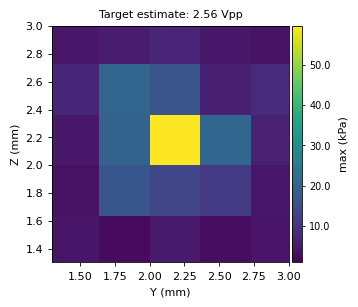

In [24]:
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable

# USER SETTINGS for the paper figure.
paper_normalize_by_max = False  # USER SETTING
paper_metric = "max"
paper_colormap = "viridis"  # e.g. seismic, coolwarm, Spectral, jet, hsv, prism, Paired, tab20, gray
paper_width_inches = 3.5
paper_dpi = 600
save_paper_figure = False

if paper_metric not in target_display_metric_maps:
    raise ValueError(f"Unknown metric: {paper_metric}")


def coordinate_edges(coordinates):
    coordinates = np.asarray(coordinates)
    if len(coordinates) < 2:
        raise ValueError("At least two coordinates are needed for cell boundaries")
    midpoints = (coordinates[:-1] + coordinates[1:]) / 2
    return np.r_[coordinates[0] - (midpoints[0] - coordinates[0]),
                 midpoints, coordinates[-1] + (coordinates[-1] - midpoints[-1])]

paper_values = target_display_metric_maps[paper_metric].copy()
paper_colorbar_label = f"{paper_metric} ({display_metric_units[paper_metric]})"
if paper_normalize_by_max:
    paper_values, paper_maximum = normalize_by_max(paper_values)
    if not np.isfinite(paper_values).any():
        raise ValueError("Cannot normalize this map: its maximum is zero or no finite data exist")
    paper_colorbar_label = f"{paper_metric} / max (dimensionless)"

with mpl.rc_context({"font.family": "DejaVu Sans", "font.size": 8,
                     "axes.linewidth": 0.6, "pdf.fonttype": 42, "ps.fonttype": 42}):
    paper_fig, paper_ax = plt.subplots(figsize=(paper_width_inches, paper_width_inches))
    mesh = paper_ax.pcolormesh(coordinate_edges(axis1_mm), coordinate_edges(axis2_mm),
                              paper_values.T,
                              cmap=paper_colormap, shading="flat", rasterized=False)
    paper_ax.set_aspect("equal")
    paper_ax.set_title(f"Target estimate: {target_voltage_vpp:g} Vpp", fontsize=8)
    paper_ax.set_xlabel(f"{axis1_name} (mm)")
    paper_ax.set_ylabel(f"{axis2_name} (mm)")
    paper_ax.set_xlim(1.3,3)
    paper_ax.set_ylim(1.3,3)
    paper_ax.tick_params(direction="out", width=0.6, length=3)
    divider = make_axes_locatable(paper_ax)
    colorbar_ax = divider.append_axes("right", size="4%", pad=0.035)
    paper_colorbar = paper_fig.colorbar(mesh, cax=colorbar_ax, format=FormatStrFormatter("%.1f"))
    paper_colorbar.set_label(paper_colorbar_label,
                            rotation=90, labelpad=6)
    paper_colorbar.ax.tick_params(width=0.6, length=2, labelsize=7)
    paper_fig.tight_layout(pad=0.5)
    if save_paper_figure:
        export_dir = project_root / "data" / "figures" 
        export_dir.mkdir(parents=True, exist_ok=True)
        voltage_tag = f"{target_voltage_vpp:g}".replace(".", "p")
        export_stem = (paper_metric.replace(" ", "_") + f"_target_{voltage_tag}Vpp"
                       + ("_normalized" if paper_normalize_by_max else ""))
        paper_fig.savefig(export_dir / f"{export_stem}.pdf", bbox_inches="tight", pad_inches=0.03)
        paper_fig.savefig(export_dir / f"{export_stem}.png", dpi=paper_dpi,
                          bbox_inches="tight", pad_inches=0.03)
        print(f"Saved PDF and {paper_dpi}-dpi PNG to {export_dir}")
    plt.show()

## Discussion summary and recommendations for future measurements


1. **Should all energy and intensity calculations use aperture-corrected values?** Yes, if corrected pressure waveforms are available at every grid point. The current notebook applies near-axis aperture correction to spatial-peak quantities only. Its scan-area energy and power are calculated from measured, sensitivity-calibrated pressure and remain uncorrected for aperture averaging. A peak correction factor should not be multiplied across the whole map without a supporting field model.

2. **Does a fixed aperture and frequency imply one correction factor everywhere?** A fixed hydrophone response can be used across the scan, but aperture averaging also depends on spatial amplitude and phase variation. The same aperture averages a uniform plane wave and a sharply focused beam differently. Constant temporal frequency and aperture therefore do not establish a spatially uniform scalar correction.

3. **How can each pixel be corrected?** Spatially resolved reconstruction can use regularized spatial/spatiotemporal deconvolution or a justified fitted beam model. Recalculate pressure, PII, pulse duration, intensity, energy and power from the reconstructed waveforms, then derive quantity-specific correction ratios if needed. Deconvolution requires suitable spatial sampling, an effective-aperture response model and consistent inter-point timing/phase. Upsampling alone does not recover unmeasured detail. [Theory](https://pmc.ncbi.nlm.nih.gov/articles/PMC9204706/), [experimental validation](https://pmc.ncbi.nlm.nih.gov/articles/PMC9136594/).

4. **Can corrected I_SPPA and I_SPTA be reported and compared with acoustic-power estimates?** The present corrections are provisional model estimates, not validated IEC-compliant results. Report measured values alongside the corrected estimates and their assumptions. Acoustic power divided by a geometric focal area estimates an area-average intensity; predicting the spatial peak requires a beam-shape/effective-area model. Define `A_eff = integral_area(I / I_peak)` and use `I_SPTA = P_TA / A_eff`. For an elliptical Gaussian intensity profile with full intensity-FWHM widths dx and dy, `A_eff = pi*dx*dy/(4*ln(2))`. Under a common pulse duration and temporal profile, `I_SPPA ≈ P_TA/(PRF*PD*A_eff)`. Focal volume alone does not yield intensity: power/volume has units W/m³, not W/m². Agreement with an independently measured acoustic power provides stronger evidence than agreement with a prediction derived from the same hydrophone scan.

5. **How do 10 Vpp results scale to 1.28 Vpp under linear operation?** Assuming a linear transducer and propagation, unchanged frequency, pulse shape, PRF and focusing, and proportional actual terminal voltage, pressure scales by `1.28/10 = 0.128`; intensity, PII, pulse energy and power scale by `0.128² = 0.016384`. Pulse duration and aperture correction factors remain unchanged under these assumptions. Scaling the latest corrected estimates gives approximately 35.57 kPa peak compressional pressure, 36.10 kPa peak rarefactional magnitude, 0.03165 W/cm² I_SPPA and 9.12 × 10⁻⁶ W/cm² I_SPTA. Use the notebook variables for exact results: these rounded values depend on the present full-pulse gate, calibration, water properties and 100 Hz PRF. Scaled results retain the original measurement and correction uncertainties; `pressure_pa` itself is still the measured, uncorrected field.

### Suggestions for future measurements

- **Resolve the beam and aperture.** At 7.37 MHz with c = 1482 m/s, wavelength is approximately 0.201 mm, so the conservative λ/2 spacing target is approximately 0.101 mm. The current 0.364 mm grid is coarser than both this target and the assumed 0.2 mm hydrophone radius. Use a transverse scan with spacing of 0.1 mm or finer at the fundamental; refine further for significant higher-frequency content and verify convergence of peaks, beam widths and area integrals. Scan through the true peak in two perpendicular directions, including offsets at ± one effective hydrophone radius. The λ/2 criterion is a conservative sampling target, not a universal guarantee of reconstruction accuracy.

- **Characterize the receiving aperture.** Obtain the frequency-dependent effective sensitive diameter/directivity for this hydrophone, rather than relying solely on its 400 µm electrode diameter. Consider a smaller-aperture hydrophone for a cross-check. Record the correction model, regularization and uncertainty. The implemented quadratic method refers to IEC 62127-1:2007 + Amendment 1:2013; assess the revised 2022 procedures before claiming compliance. [Onda specifications](https://www.ondacorp.com/capsule-hydrophone/), [IEC revision](https://webstore.iec.ch/en/publication/75130).

- **Preserve timing and complete pulses.** Use a common trigger, record time origins and trigger settings, and distinguish acquisition jitter from genuine propagation delay. Capture pre-pulse background, the complete pulse and ring-down. Inspect cumulative-energy curves and set a justified pulse gate, especially at weak off-axis points. Record actual PRF and cycle count; use measured `PD = 1.25*(t90 − t10)` for intensity reporting rather than nominal `no_cycles/f`.

- **Capture pulse variability and noise.** Save individual pulses and repeat scans to estimate repeatability, drift and uncertainty. When individual pulses are available, calculate p²-based metrics for each pulse and average the metrics. Squaring an averaged waveform does not include pulse-to-pulse variance. Acquire background/no-drive traces and document any baseline or noise correction.

- **Verify linear voltage scaling.** Measure actual loaded voltage across the transducer and repeat pressure measurements at several drive levels, including 1.28 and 10 Vpp where practical. Test pressure proportionality to voltage, intensity proportionality to voltage squared, and stability of waveform shape, harmonics and beam width. Characterize amplifier/transducer loading; signal-generator settings alone may not equal terminal voltage.

- **Check bandwidth and calibration.** Confirm the oscilloscope load matches the calibration (the supplied hydrophone/preamplifier calibration specifies 50 Ω). Inspect the spectrum and choose temporal sampling appropriate to the highest significant component. Approximately 100 MS/s provides 13.6 samples per fundamental cycle at 7.37 MHz, but only 5 per cycle at 20 MHz. Use frequency-dependent calibration/deconvolution when a scalar sensitivity is inadequate; restricting a plot to 20 MHz does not remove out-of-band content or calibrate it.

- **Measure environment and scan geometry.** Record water temperature, degassing, medium and actual density/sound-speed assumptions. Confirm that the Y–Z scan is perpendicular to propagation; X propagation is currently an assumption. Extend the scan to capture sidelobes and tails, assess boundary energy and repeat with a wider area to check integral convergence. A single focal-plane scan determines neither focal volume nor the global three-dimensional spatial peak; add axial and transverse measurements if these are needed.

- **Independently validate acoustic power.** Measure acoustic output under matching drive/pulse conditions, for example with a suitable radiation-force balance, and distinguish time-average from pulse-average power. Compare with the hydrophone scan-area energy/power using consistent units and temporal conventions. Report a combined uncertainty budget including calibration, aperture response, positioning, temporal/spatial sampling, gating, noise, repeatability and the voltage-scaling model. Until these are established, label corrected peaks and scaled predictions as estimates rather than validated absolute outputs.


### Pulse-gate/noise audit update

The full-trace gate inflated off-axis PD by integrating background noise. Defaults now use a 42–52 µs pulse gate and a 40.05–42 µs noise window, remove the baseline mean for intensity processing, subtract expected noise energy, and mask unresolved energy-quantile durations. These windows must be verified for every point; pulse tails outside the gate are omitted. Negative per-point energy estimates are preserved for spatial sums. Previously quoted numerical estimates above predate this change; rerun the reports for current values. A noise-dominated duration cannot be recovered reliably by gating alone, and clipping each `p² − noise_variance` sample to zero is avoided because it creates positive bias.